# Random Forest - Ensemble Learning [ Manual Bagging Demo ]

**What is Random Forest?**  
- Random Forest is a powerful **ensemble learning** method that builds many decision trees and combines their predictions (majority vote for classification, averaging for regression). It reduces overfitting and variance through two key techniques:
- **Bootstrap sampling** (row sampling with replacement)
- **Goal of this notebook**: Understand how diversity among trees leads to better generalization.

In [79]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.datasets import make_classification
import random 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

###  Generating Synthetic Classification Data
We create a toy binary classification dataset using `make_classification`.  
All 5 features are informative, no redundancy — without real-world noise.

In [81]:
# Generate synthetic data: 5 informative features, binary target
X, y = make_classification(
    n_features=5, 
    n_informative=5, 
    n_clusters_per_class=1, 
    n_redundant=0,
    random_state=42  # Reproducibility
)

# Convert to pandas DataFrame (easier to work with)
data = pd.DataFrame(X, columns=['col_1', 'col_2', 'col_3', 'col_4', 'col_5'])
data['target'] = y
data.head(2)

,col_1,col_2,col_3,col_4,col_5,target
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
1,3.243492,1.666651,3.179016,-0.825861,0.778528,1


###  Bootstrap Sampling (Key Idea of Bagging)

In Random Forest we create many **bootstrap samples** (sampling rows with replacement).  
Each tree sees slightly different data → diversity → reduced variance.

Use a simple 20% sample size for the demo.

In [83]:
def sample_rows(data, percent):
    """
    Bootstrap sampling function (core of Bagging).
    Samples rows with replacement so some rows appear multiple times.
    This creates diversity among the trees.
    """
    sample_size = int(percent * data.shape[0])
    return data.sample(n=sample_size, replace=True, random_state=42)  # Fixed seed for demo

# Create 3 different bootstrap samples
data1 = sample_rows(data, 0.2)
data2 = sample_rows(data, 0.2)
data3 = sample_rows(data, 0.2)

print("Sample shape:", data3.shape)
print(data3.head(2))

Sample shape: (20, 6)
       col_1     col_2     col_3     col_4     col_5  target
51  1.384690  1.137195  1.914034  0.465929 -0.772672       1
92 -1.131826 -0.184478 -1.149590  2.724858 -2.395793       1


### Training Individual Decision Trees (Base Learners)

Each tree is trained on a different bootstrap sample.  
In a full Random Forest we would also randomly select features at each split.

In [85]:
# Create 3 independent decision trees
decision_tree1 = DecisionTreeClassifier(random_state=42)
decision_tree2 = DecisionTreeClassifier(random_state=42)
decision_tree3 = DecisionTreeClassifier(random_state=42)

# Train each tree on its own bootstrap sample
decision_tree1.fit(data1.iloc[:, 0:5], data1.iloc[:, -1]), decision_tree2.fit(data2.iloc[:, 0:5], data2.iloc[:, -1]), decision_tree3.fit(data3.iloc[:, 0:5], data3.iloc[:, -1])

(DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(random_state=42))

### Visualizing the Trees

Look at how different the trees are!  
Different training data → different splits → diversity.

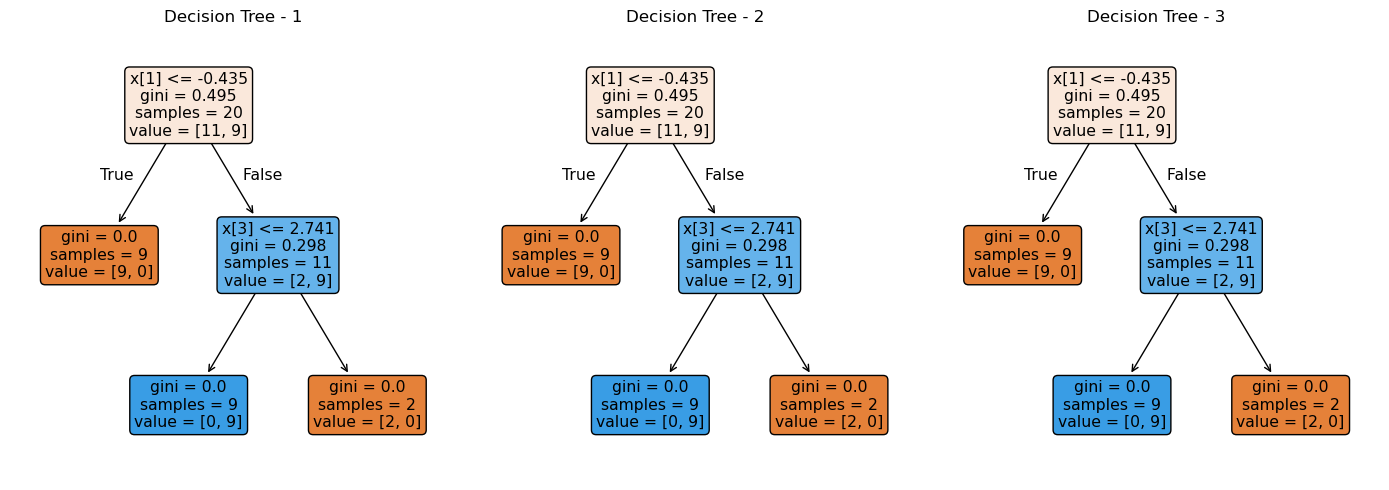

In [87]:
plt.figure(figsize=(14, 5))

plt.subplot(131)
plot_tree(decision_tree1, filled=True, rounded=True)
plt.title("Decision Tree - 1")

plt.subplot(132)
plot_tree(decision_tree2, filled=True, rounded=True)
plt.title("Decision Tree - 2")

plt.subplot(133)
plot_tree(decision_tree3, filled=True, rounded=True)
plt.title("Decision Tree - 3")

plt.tight_layout()
plt.show()

### Making Predictions (Ensemble Voting Concept)

Each tree can give a different prediction on the same point.  
**Real Random Forest** takes the **majority vote** across hundreds of trees.

In [89]:
# Test point (original code used 3 features - trees expect 5)
# For correct prediction we take first 3 features + pad zeros (or better: use a real sample row)
test_point = np.array([-0.522901, -2.108286, -2.737741, 0, 0]).reshape(1, 5)  

print("Prediction by Decision Tree - 1 ::", decision_tree1.predict(test_point))
print("Prediction by Decision Tree - 2 ::", decision_tree2.predict(test_point))
print("Prediction by Decision Tree - 3 ::", decision_tree3.predict(test_point))

# In real RF we would do majority vote:
# votes = [dt1.predict(...), dt2.predict(...), dt3.predict(...)]
# final_prediction = np.bincount(votes).argmax()

Prediction by Decision Tree - 1 :: [0]
Prediction by Decision Tree - 2 :: [0]
Prediction by Decision Tree - 3 :: [0]


#
---

# Random Forest by Feature Sampling 

In [92]:
def sample_feature(data,percent):
    """
      - Randomly selects a subset of features for each tree
    """  
    cols = random.sample(data.columns.tolist()[:-1],int(percent*(data.shape[1]-1)))
    new_df = data[cols]
    new_df['target'] = data['target']
    return new_df


data4 = sample_feature(data,0.7)
data5 = sample_feature(data,0.7)
data6 = sample_feature(data,0.7)
print(data4.shape)
print(data4.head(2))    

(100, 4)
      col_2     col_3     col_5  target
0 -3.861208  1.530963  1.030284       0
1  1.666651  3.179016  0.778528       1


### Training Individual Decision Trees 

In [94]:
decision_tree1.fit(data4.iloc[:,0:3],data4.iloc[:,-1]), decision_tree2.fit(data5.iloc[:,0:3],data5.iloc[:,-1]), decision_tree3.fit(data6.iloc[:,0:3],data6.iloc[:,-1])

(DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(random_state=42))

### Visualizing the Trees

Look at how different the trees are!  
Different training data → different splits → diversity.

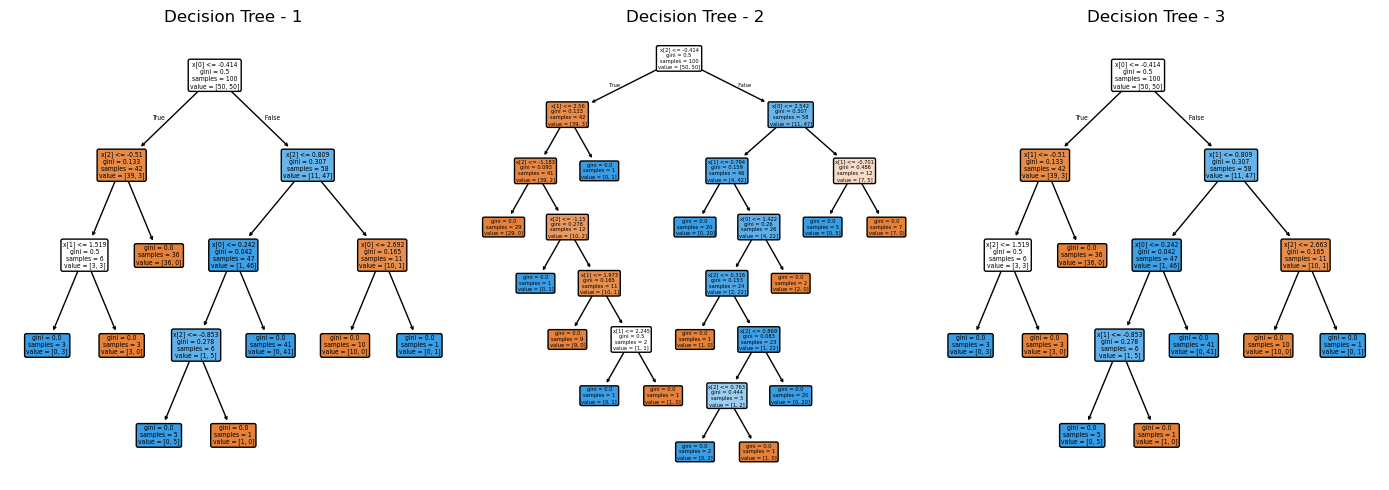

In [96]:
plt.figure(figsize=(14, 5))

plt.subplot(131)
plot_tree(decision_tree1, filled=True, rounded=True)
plt.title("Decision Tree - 1")

plt.subplot(132)
plot_tree(decision_tree2, filled=True, rounded=True)
plt.title("Decision Tree - 2")

plt.subplot(133)
plot_tree(decision_tree3, filled=True, rounded=True)
plt.title("Decision Tree - 3")

plt.tight_layout()
plt.show()

### Making Predictions (Ensemble Voting Concept)

Each tree can give a different prediction on the same point.  
**Real Random Forest** takes the **majority vote** across hundreds of trees.

In [98]:
print("Prediction by Decision Tree - 1 ::",decision_tree1.predict(np.array([-0.522901,-2.108286,-2.737741]).reshape(1,3)))
print("Prediction by Decision Tree - 2 ::",decision_tree2.predict(np.array([-0.522901,-2.108286,-2.737741]).reshape(1,3)))
print("Prediction by Decision Tree - 3 ::",decision_tree3.predict(np.array([-0.522901,-2.108286,-2.737741]).reshape(1,3)))

# In real RF we would do majority vote:
# votes = [dt1.predict(...), dt2.predict(...), dt3.predict(...)]

Prediction by Decision Tree - 1 :: [1]
Prediction by Decision Tree - 2 :: [0]
Prediction by Decision Tree - 3 :: [1]


#
---

## Random Forest by Both Sampling - [ Row + Feature Sampling]

In [100]:
def combined_sampling(data,row_percent,col_percent):
  new_df = sample_rows(data,row_percent)
  return sample_feature(new_df,col_percent)

data7 = combined_sampling(data,0.3,0.7)
data8 = combined_sampling(data,0.3,0.7)
data9 = combined_sampling(data,0.3,0.7)
print(data9.shape)
print(data9.head(2))    

(30, 4)
       col_1     col_4     col_2  target
51  1.384690  0.465929  1.137195       1
92 -1.131826  2.724858 -0.184478       1


### Training Individual Decision Trees 

In [102]:
decision_tree1.fit(data7.iloc[:,0:3],data7.iloc[:,-1]), decision_tree2.fit(data8.iloc[:,0:3],data8.iloc[:,-1]), decision_tree3.fit(data9.iloc[:,0:3],data9.iloc[:,-1])

(DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(random_state=42))

### Visualizing the Trees

Look at how different the trees are!  
Different training data → different splits → diversity.

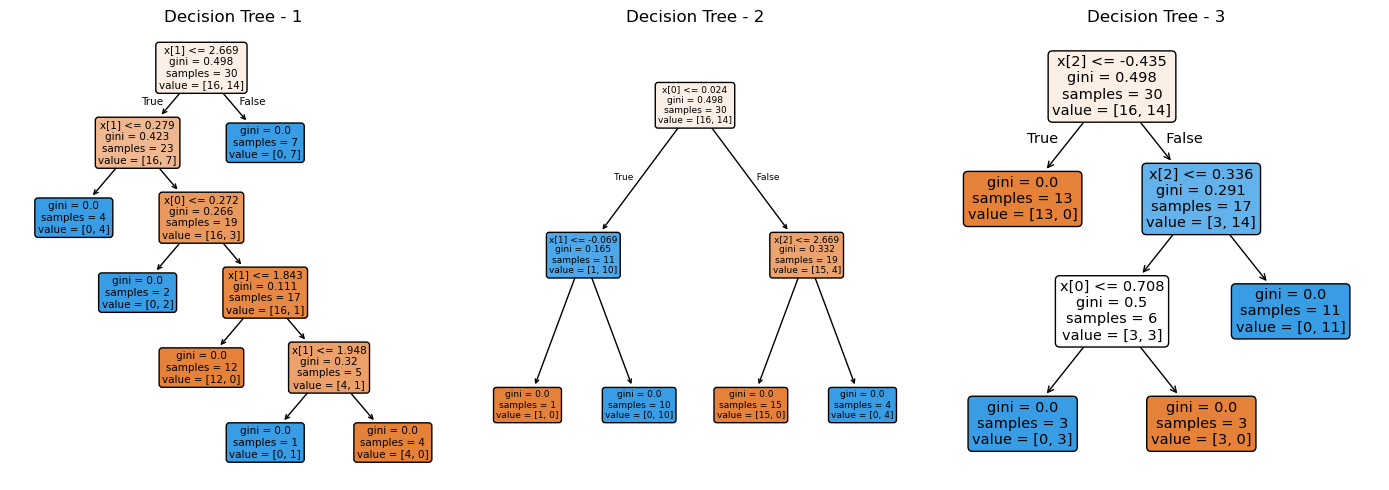

In [104]:
plt.figure(figsize=(14, 5))

plt.subplot(131)
plot_tree(decision_tree1, filled=True, rounded=True)
plt.title("Decision Tree - 1")

plt.subplot(132)
plot_tree(decision_tree2, filled=True, rounded=True)
plt.title("Decision Tree - 2")

plt.subplot(133)
plot_tree(decision_tree3, filled=True, rounded=True)
plt.title("Decision Tree - 3")

plt.tight_layout()
plt.show()

### Making Predictions (Ensemble Voting Concept)

Each tree can give a different prediction on the same point.  
**Real Random Forest** takes the **majority vote** across hundreds of trees.

In [106]:
print("Prediction by Decision Tree - 1 ::",decision_tree1.predict(np.array([-0.522901,-2.108286,-2.737741]).reshape(1,3)))
print("Prediction by Decision Tree - 2 ::",decision_tree2.predict(np.array([-0.522901,-2.108286,-2.737741]).reshape(1,3)))
print("Prediction by Decision Tree - 3 ::",decision_tree3.predict(np.array([-0.522901,-2.108286,-2.737741]).reshape(1,3)))

Prediction by Decision Tree - 1 :: [1]
Prediction by Decision Tree - 2 :: [0]
Prediction by Decision Tree - 3 :: [0]
